In [ ]:
# CELL 1: Imports and Load Dataset
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Test images shape     :", x_test.shape)
print("Test labels shape     :", y_test.shape)
print("Pixel value range     :", x_train.min(), "–", x_train.max())
print("Classes               :", class_names)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Test images shape     : (10000, 32, 32, 3)
Test labels shape     : (10000, 1)
Pixel value range     : 0 – 255
Classes               : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# Recreate normalized data (needed for flattening)
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

In [ ]:
# CELL 16:
# MEMBER 6: Feature Engineering — Image Flattening
# Step 1: Check current image shape (Random Forest needs 1D data, not 3D)
print("Image shape before flattening:", x_train_norm[0].shape)

# Step 2: Reshape each image from 32x32x3 into a single row of 3072 numbers
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], -1)

print("Shape after flattening:", x_train_flat.shape)

Image shape before flattening: (32, 32, 3)
Shape after flattening: (50000, 3072)


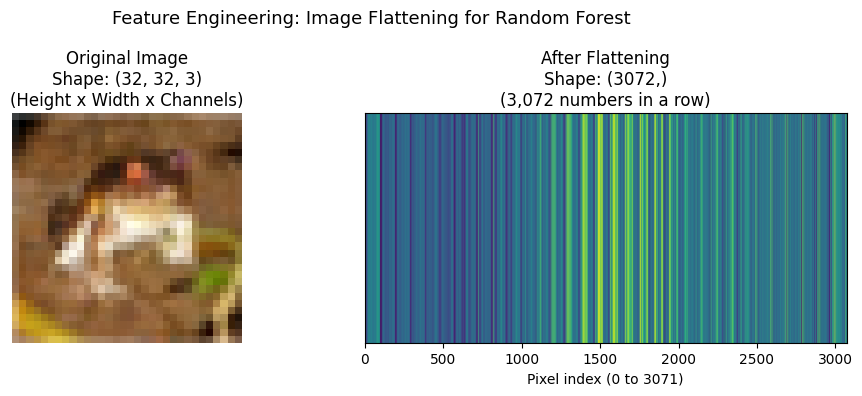

Before flattening: (32, 32, 3) — spatial structure preserved
After flattening:  (3072,) — spatial structure lost
Random Forest sees 3,072 independent numbers, not a 32x32 image


In [ ]:
# CELL 17      : Feature Engineering Visualization — Original vs Flattened shape
# This visual shows exactly what flattening does to an image
# A 32x32x3 image (3D spatial structure) becomes a 1D strip of 3,072 numbers
# This demonstrates WHY Random Forest loses spatial information after flattening

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Show original image (first training image)
axes[0].imshow(x_train[0])
axes[0].set_title(f'Original Image\nShape: {x_train[0].shape}\n(Height x Width x Channels)')
axes[0].axis('off')

# Show flattened version as a 1D colour strip
axes[1].imshow(x_train_flat[0].reshape(1, -1), aspect='auto', cmap='viridis')
axes[1].set_title(f'After Flattening\nShape: {x_train_flat[0].shape}\n(3,072 numbers in a row)')
axes[1].set_yticks([])
axes[1].set_xlabel('Pixel index (0 to 3071)')

plt.suptitle('Feature Engineering: Image Flattening for Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Before flattening: {x_train[0].shape} — spatial structure preserved")
print(f"After flattening:  {x_train_flat[0].shape} — spatial structure lost")
print(f"Random Forest sees 3,072 independent numbers, not a 32x32 image")